# Risk-Only Prediction Model (Anonymized Data)

This notebook builds a reproducible **risk-only** pipeline from anonymized program data.

It will:
- Engineer an ordinal risk tier target (`LOW`, `MEDIUM`, `HIGH`) from arrears and loan status rules
- Train a multiclass classifier for risk tier
- Train a regressor for continuous risk score proxy
- Evaluate, calibrate, and export only risk artifacts

All employment and revenue prediction paths are intentionally excluded.

## 1) Imports & Setup

In [1]:
import io
import json
import warnings
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    roc_auc_score,
    cohen_kappa_score,
    brier_score_loss,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import PartialDependenceDisplay

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

try:
    import lightgbm as lgb
except Exception:
    lgb = None

try:
    from xgboost import XGBClassifier, XGBRegressor
except Exception:
    XGBClassifier, XGBRegressor = None, None

def find_ml_dir(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for c in candidates:
        if (c / "ml" / "Anomynized data").exists():
            return c / "ml"
        if (c / "Anomynized data").exists():
            return c
    raise FileNotFoundError(
        f"Could not locate ML data directory from {start}. Expected an 'ml/Anomynized data' or 'Anomynized data' folder in current/parent paths."
    )

BASE_DIR = Path.cwd().resolve()
ML_DIR = find_ml_dir(BASE_DIR)
ANON_DIR = ML_DIR / "Anomynized data" / "Anomynized data" / "Anomynized data"

ARTIFACTS_DIR = ML_DIR / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"
PREDICTIONS_DIR = ARTIFACTS_DIR / "predictions"
CHARTS_DIR = ML_DIR / "charts"

for d in [ARTIFACTS_DIR, MODELS_DIR, METRICS_DIR, PREDICTIONS_DIR, CHARTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INVESTMENT_PATH = ANON_DIR / "Investment data_all clients_RW-KE-ET-SS_2021-2025_Inkomoko.csv"
BASELINE_PATH = ANON_DIR / "baseline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv"
ENDLINE_PATH = ANON_DIR / "endline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv"

print(f"BASE_DIR: {BASE_DIR}")
print(f"ML_DIR: {ML_DIR}")
print(f"Anonymized data dir exists: {ANON_DIR.exists()} -> {ANON_DIR}")
print(f"Investment exists: {INVESTMENT_PATH.exists()} -> {INVESTMENT_PATH}")
print(f"Baseline exists: {BASELINE_PATH.exists()} -> {BASELINE_PATH}")
print(f"Endline exists: {ENDLINE_PATH.exists()} -> {ENDLINE_PATH}")

def load_csv_with_fallback(path: Path) -> pd.DataFrame:
    # Try common encodings first.
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue

    # Last resort: decode bytes with replacement and parse from memory.
    raw = path.read_bytes()
    text = raw.decode("utf-8", errors="replace")
    return pd.read_csv(io.StringIO(text))

BASE_DIR: /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/notebooks
ML_DIR: /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml
Anonymized data dir exists: True -> /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/Anomynized data/Anomynized data/Anomynized data
Investment exists: True -> /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/Anomynized data/Anomynized data/Anomynized data/Investment data_all clients_RW-KE-ET-SS_2021-2025_Inkomoko.csv
Baseline exists: True -> /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/Anomynized data/Anomynized data/Anomynized data/baseline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv
Endline exists: True -> /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/Anomynized data/Anomynized data/Anomynized dat

## 2) Data Loading

Load anonymized investment, baseline, and endline datasets with robust decoding and inspect schema coverage.

In [2]:
investment_df = load_csv_with_fallback(INVESTMENT_PATH)
baseline_df = load_csv_with_fallback(BASELINE_PATH)
endline_df = load_csv_with_fallback(ENDLINE_PATH)

print("Investment shape:", investment_df.shape)
print("Baseline shape  :", baseline_df.shape)
print("Endline shape   :", endline_df.shape)

print("\nInvestment columns sample:", investment_df.columns[:15].tolist())
print("Baseline columns:", baseline_df.columns.tolist())
print("Endline columns :", endline_df.columns.tolist())

display(investment_df.head(3))
display(baseline_df.head(3))
display(endline_df.head(3))

Investment shape: (35020, 53)
Baseline shape  : (8976, 21)
Endline shape   : (8976, 26)

Investment columns sample: ['loanNumber', 'ClientId', 'BaselineEndlineClientId', 'country', 'purpose', 'strata', 'age', 'gender', 'gender.1', 'nationality', 'cycle', 'province', 'district', 'submissionDate', 'approvalDate']
Baseline columns: ['client_id', 'country', 'survey_date', 'age', 'gender', 'strata', 'client_location', 'nationality', 'education_level', 'business_sector', 'only_income_earner', 'number_of_people_reponsible', 'business_location', 'is_business_registered', 'has_access_to_finance_in_past6months', 'have_bank_account', 'monthly_customer', 'kept_sales_record', 'job_created', 'revenue', 'hh_expense']
Endline columns : ['client_id', 'country', 'survey_date', 'age', 'gender', 'strata', 'client_location', 'nationality', 'education_level', 'business_sector', 'only_income_earner', 'number_of_people_reponsible', 'business_location', 'is_business_registered', 'has_access_to_finance_in_past6

,loanNumber,ClientId,BaselineEndlineClientId,country,purpose,strata,age,gender,gender.1,nationality,...,lastInterestAmount,lastFeesAmount,lastLateFeesAmount,lastExcessAmount,daysInArrears,installmentInArrears,lastPaymentDate,loanStatus,industrySectorOfActivity,businessSubSector
0,ED7D68959A89,9B2D5B4678781E53,16536C353F161D89D5E4,Rwanda,Working Capital,Host Community,44.0,Male,Male,Rwanda,...,3.956,0.0,0.0,0.000,0,0,2024-02-29,Closed Obligations Met,NaN,NaN
1,9CED183B2BA5,9B2D5B4678781E53,16536C353F161D89D5E4,Rwanda,Working Capital,Host Community,44.0,Male,Male,Rwanda,...,0.000,0.0,0.0,0.000,295,8,2026-01-15,Active,NaN,NaN
2,B63E5B90C27B,9B2D5B4678781E53,B62567A3120BD187B018,Rwanda,Working Capital,Host Community,22.0,Male,Male,Rwanda,...,13.186,0.0,0.0,0.021,0,0,2024-06-13,Overpaid,NaN,NaN


,client_id,country,survey_date,age,gender,strata,client_location,nationality,education_level,business_sector,...,number_of_people_reponsible,business_location,is_business_registered,has_access_to_finance_in_past6months,have_bank_account,monthly_customer,kept_sales_record,job_created,revenue,hh_expense
0,EB2E2F413E84742BFAA4,Rwanda,06/09/2022,34,Female,Refugee,Nyabiheke Camp,Congolese,Finished Primary,Wholesale & General Trading,...,4.0,Nyabiheke Camp,No,No,Yes,400.0,No,1.0,281.162137,NaN
1,3AFDDC837F7708726702,Rwanda,06/10/2022,34,Male,Refugee,Nyabiheke Camp,Congolese,Finished High School And Above,Education,...,3.0,Nyabiheke Camp,No,No,Yes,300.0,No,1.0,56.232427,NaN
2,88293FF22ABB9BB12782,Rwanda,06/09/2022,32,Male,Refugee,Nyabiheke Camp,Congolese,Finished High School And Above,Education,...,4.0,Nyabiheke Camp,No,Yes,Yes,560.0,Yes,1.0,112.464855,NaN


,client_id,country,survey_date,age,gender,strata,client_location,nationality,education_level,business_sector,...,monthly_customer,kept_sales_record,job_created,revenue,hh_expense,nps_detractor,nps_passive,nps_promoter,satisfied_yes,satisfied_no
0,EB2E2F413E84742BFAA4,Rwanda,16/12/2022,34,Female,Refugee,Gatsibo,Congolese,Attended Primary,NaN,...,50.0,Yes,1.0,4.686036,NaN,0.0,1.0,0.0,1.0,0.0
1,3AFDDC837F7708726702,Rwanda,18/12/2022,34,Male,Refugee,Gatsibo,Congolese,Finished High School Graduate,NaN,...,55.0,Yes,2.0,56.232427,NaN,0.0,1.0,0.0,1.0,0.0
2,88293FF22ABB9BB12782,Rwanda,15/12/2022,32,Male,Refugee,Gatsibo,Congolese,Finished High School Graduate,NaN,...,200.0,Yes,1.0,93.720712,NaN,0.0,1.0,0.0,1.0,0.0


## 3) Data Cleaning & Target Engineering

Normalize identifiers, parse dates, clean numeric fields, and engineer risk targets (`risk_tier_3m`, `risk_score_3m`) from anonymized loan behavior.

In [3]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = []
    seen = {}
    for c in df.columns:
        name = str(c).strip()
        if name in seen:
            seen[name] += 1
            name = f"{name}_{seen[name]}"
        else:
            seen[name] = 0
        cols.append(name)
    out = df.copy()
    out.columns = cols
    return out

def parse_dates(df: pd.DataFrame, date_cols: List[str], dayfirst: bool = False) -> pd.DataFrame:
    out = df.copy()
    for c in date_cols:
        if c in out.columns:
            out[c] = pd.to_datetime(out[c], errors="coerce", dayfirst=dayfirst)
    return out

def to_num(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("#REF!", "", regex=False)
                .str.replace("$", "", regex=False)
            )
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

investment = normalize_columns(investment_df)
baseline = normalize_columns(baseline_df)
endline = normalize_columns(endline_df)

investment = parse_dates(investment, ["submissionDate", "approvalDate", "disbursementDate", "lastPaymentDate"], dayfirst=False)
baseline = parse_dates(baseline, ["survey_date"], dayfirst=True)
endline = parse_dates(endline, ["survey_date"], dayfirst=True)

inv_num_cols = [
    "age", "cycle", "termsDuration", "daysInArrears", "installmentInArrears",
    "appliedAmount", "approvedAmount", "disbursedAmount", "actualPaymentAmount",
    "principalPaid", "interestPaid", "insuranceFeePaid", "totalLateFeesPaid",
    "excessAmountPaid", "interestWaived", "currentBalance", "principalBalance",
    "interestBalance", "feesBalance", "amountPastDue", "principalPastDue",
    "interestPastDue", "feesPastDue", "scheduledPrincipalAmount",
    "scheduledInterestAmount", "scheduledFeesAmount", "scheduledPaymentAmount",
    "lastPaymentAmount", "lastPrincipalAmount", "lastInterestAmount",
    "lastFeesAmount", "lastLateFeesAmount", "lastExcessAmount",
    "DisbursementYear",
]
baseline_num_cols = ["age", "number_of_people_reponsible", "monthly_customer", "job_created", "revenue", "hh_expense"]
endline_num_cols = baseline_num_cols + ["nps_detractor", "nps_passive", "nps_promoter", "satisfied_yes", "satisfied_no"]

investment = to_num(investment, inv_num_cols)
baseline = to_num(baseline, baseline_num_cols)
endline = to_num(endline, endline_num_cols)

# Harmonize IDs for joins.
for df, col in [(investment, "BaselineEndlineClientId"), (investment, "ClientId"), (baseline, "client_id"), (endline, "client_id")]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Aggregate survey context (prefer latest endline, then baseline fallback).
survey_cols = [
    "client_id", "age", "gender", "strata", "nationality", "education_level", "business_sector",
    "business_location", "is_business_registered", "has_access_to_finance_in_past6months",
    "have_bank_account", "monthly_customer", "kept_sales_record", "revenue", "hh_expense",
    "nps_detractor", "nps_passive", "nps_promoter", "satisfied_yes", "satisfied_no", "survey_date",
]
survey_all = pd.concat([baseline.assign(_src="baseline"), endline.assign(_src="endline")], ignore_index=True, sort=False)
survey_all = survey_all.sort_values(["client_id", "survey_date", "_src"])
survey_latest = survey_all.groupby("client_id", as_index=False).tail(1)

# Select latest loan state per client for label and feature consistency.
loan_sort_col = "disbursementDate" if "disbursementDate" in investment.columns else "approvalDate"
investment = investment.sort_values(["ClientId", loan_sort_col])
loan_latest = investment.groupby("ClientId", as_index=False).tail(1).copy()

# Core engineered loan features.
loan_latest["repayment_ratio"] = loan_latest["actualPaymentAmount"] / loan_latest["scheduledPaymentAmount"].replace(0, np.nan)
loan_latest["utilization_ratio"] = loan_latest["disbursedAmount"] / loan_latest["approvedAmount"].replace(0, np.nan)
loan_latest["past_due_ratio"] = loan_latest["amountPastDue"] / loan_latest["scheduledPaymentAmount"].replace(0, np.nan)
loan_latest["principal_completion_ratio"] = loan_latest["principalPaid"] / loan_latest["disbursedAmount"].replace(0, np.nan)

def map_risk_tier(row: pd.Series) -> str:
    status = str(row.get("loanStatus", "")).strip().lower()
    days = row.get("daysInArrears", np.nan)
    past_due = row.get("amountPastDue", np.nan)
    days = 0 if pd.isna(days) else float(days)
    past_due = 0 if pd.isna(past_due) else float(past_due)

    if "written off" in status or days > 30 or past_due > 0 and days > 15:
        return "HIGH"
    if "active" in status or (0 < days <= 30) or past_due > 0:
        return "MEDIUM"
    if "obligations met" in status or "overpaid" in status or days == 0:
        return "LOW"
    return "MEDIUM"

loan_latest["risk_tier_3m"] = loan_latest.apply(map_risk_tier, axis=1)

# Continuous risk score proxy scaled to [0, 1].
score_raw = (
    loan_latest["daysInArrears"].fillna(0).clip(lower=0) * 0.55
    + loan_latest["amountPastDue"].fillna(0).clip(lower=0).rank(pct=True) * 100 * 0.30
    + loan_latest["installmentInArrears"].fillna(0).clip(lower=0) * 0.15
)
score_raw = score_raw.fillna(0)
max_raw = score_raw.max() if score_raw.max() > 0 else 1.0
loan_latest["risk_score_3m"] = (score_raw / max_raw).clip(0, 1)

model_df = loan_latest.merge(
    survey_latest,
    left_on="BaselineEndlineClientId",
    right_on="client_id",
    how="left",
    suffixes=("_loan", "_survey"),
)

for c in model_df.columns:
    if model_df[c].dtype.kind in "fiu":
        model_df[c] = model_df[c].replace([np.inf, -np.inf], np.nan)

print("Model dataset shape:", model_df.shape)
print("Risk tier distribution:")
display(model_df["risk_tier_3m"].value_counts(dropna=False).to_frame("count"))
display(model_df[["ClientId", "BaselineEndlineClientId", "risk_tier_3m", "risk_score_3m"]].head(5))

Model dataset shape: (21042, 86)
Risk tier distribution:


,count
risk_tier_3m,
LOW,9866
HIGH,7341
MEDIUM,3835


,ClientId,BaselineEndlineClientId,risk_tier_3m,risk_score_3m
0,0,nan,MEDIUM,0.008640
1,0003AE950551FEE1,nan,MEDIUM,0.026876
2,0003D4CBAB7A1BE3,nan,MEDIUM,0.008640
3,0005CD456FF5807A,nan,MEDIUM,0.008640
4,000A31302EB10C56,nan,HIGH,0.038325


## 4) Feature Set Assembly

Prepare model matrix with leakage-safe feature selection for risk-only training.

In [4]:
TARGET_ORDINAL = "risk_tier_3m"
TARGET_SCORE = "risk_score_3m"

# Ensure chronological ordering for time split.
if "disbursementDate" in model_df.columns:
    model_df = model_df.sort_values("disbursementDate")
elif "approvalDate" in model_df.columns:
    model_df = model_df.sort_values("approvalDate")
else:
    model_df = model_df.reset_index(drop=True)

model_df = model_df.dropna(subset=[TARGET_ORDINAL, TARGET_SCORE]).reset_index(drop=True)

risk_order = ["LOW", "MEDIUM", "HIGH"]
model_df[TARGET_ORDINAL] = model_df[TARGET_ORDINAL].str.upper()
model_df = model_df[model_df[TARGET_ORDINAL].isin(risk_order)].copy()

leakage_cols = {
    TARGET_ORDINAL, TARGET_SCORE,
    "ClientId", "BaselineEndlineClientId", "client_id",
    "loanNumber", "submissionDate", "approvalDate", "disbursementDate", "lastPaymentDate",
}
feature_cols = [c for c in model_df.columns if c not in leakage_cols]

X = model_df[feature_cols].copy()
y_ord = model_df[TARGET_ORDINAL].copy()
y_score = model_df[TARGET_SCORE].copy()

split_idx = max(1, int(len(model_df) * 0.8))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_ord, y_test_ord = y_ord.iloc[:split_idx], y_ord.iloc[split_idx:]
y_train_score, y_test_score = y_score.iloc[:split_idx], y_score.iloc[split_idx:]

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]),
            cat_cols,
        ),
    ],
    remainder="drop",
)

print(f"Rows total/train/test: {len(model_df)} / {len(X_train)} / {len(X_test)}")
print(f"Features: {len(feature_cols)} (num={len(num_cols)}, cat={len(cat_cols)})")
display(model_df[[TARGET_ORDINAL, TARGET_SCORE]].head(5))

Rows total/train/test: 21042 / 16833 / 4209
Features: 76 (num=49, cat=27)


,risk_tier_3m,risk_score_3m
0,LOW,0.00864
1,LOW,0.00864
2,LOW,0.00864
3,LOW,0.00864
4,LOW,0.00864


## 5) Baseline Risk Models

Train baseline models for risk tier classification and risk score regression.

In [5]:
ord_map = {k: i for i, k in enumerate(risk_order)}
y_train_ord_num = y_train_ord.map(ord_map)
y_test_ord_num = y_test_ord.map(ord_map)

baseline_ord = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, random_state=SEED, multi_class="multinomial")),
])
baseline_ord.fit(X_train, y_train_ord_num)

baseline_score = Pipeline([
    ("prep", preprocess),
    ("reg", RandomForestRegressor(n_estimators=250, random_state=SEED, n_jobs=-1)),
])
baseline_score.fit(X_train, y_train_score)

base_ord_pred = baseline_ord.predict(X_test)
base_ord_proba = baseline_ord.predict_proba(X_test)
base_score_pred = np.clip(baseline_score.predict(X_test), 0, 1)

print("Baseline models trained")
print("Baseline classifier:", baseline_ord["clf"].__class__.__name__)
print("Baseline regressor :", baseline_score["reg"].__class__.__name__)

Baseline models trained
Baseline classifier: LogisticRegression
Baseline regressor : RandomForestRegressor


## 6) Advanced Risk Models

Use boosted models when available, with RandomForest fallback.

In [6]:
advanced_models = {}

FAST_TRAIN = True
cv_splits = 2 if FAST_TRAIN else 3
search_iters = 3 if FAST_TRAIN else 6

if lgb is not None:
    adv_clf = lgb.LGBMClassifier(
        random_state=SEED,
        objective="multiclass",
        num_class=3,
        n_estimators=200 if FAST_TRAIN else 400,
    )
    clf_params = {
        "clf__learning_rate": [0.05, 0.1],
        "clf__num_leaves": [15, 31],
        "clf__subsample": [0.8, 1.0],
    }
elif XGBClassifier is not None:
    adv_clf = XGBClassifier(
        random_state=SEED,
        objective="multi:softprob",
        eval_metric="mlogloss",
        num_class=3,
        tree_method="hist",
        n_estimators=220 if FAST_TRAIN else 400,
    )
    clf_params = {
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [3, 5],
        "clf__subsample": [0.8, 1.0],
    }
else:
    adv_clf = RandomForestClassifier(random_state=SEED, n_estimators=350, n_jobs=-1)
    clf_params = {
        "clf__max_depth": [8, 12, None],
        "clf__min_samples_leaf": [1, 3],
    }

adv_ord_pipe = Pipeline([("prep", preprocess), ("clf", adv_clf)])
cv = TimeSeriesSplit(n_splits=cv_splits)
search_ord = RandomizedSearchCV(
    adv_ord_pipe,
    clf_params,
    n_iter=search_iters,
    scoring="f1_weighted",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
)
search_ord.fit(X_train, y_train_ord_num)

if lgb is not None:
    adv_reg = lgb.LGBMRegressor(random_state=SEED, n_estimators=220 if FAST_TRAIN else 400, learning_rate=0.05)
elif XGBRegressor is not None:
    adv_reg = XGBRegressor(random_state=SEED, eval_metric="rmse", tree_method="hist", n_estimators=220 if FAST_TRAIN else 400)
else:
    adv_reg = RandomForestRegressor(random_state=SEED, n_estimators=350, n_jobs=-1)

adv_score_pipe = Pipeline([("prep", preprocess), ("reg", adv_reg)])
adv_score_pipe.fit(X_train, y_train_score)

advanced_models["risk_tier"] = search_ord.best_estimator_
advanced_models["risk_score"] = adv_score_pipe

adv_ord_pred = advanced_models["risk_tier"].predict(X_test)
adv_ord_proba = advanced_models["risk_tier"].predict_proba(X_test)
adv_score_pred = np.clip(advanced_models["risk_score"].predict(X_test), 0, 1)

print("Advanced risk models trained")
print("Best risk-tier model:", advanced_models["risk_tier"]["clf"].__class__.__name__)
print("Risk-score model:", advanced_models["risk_score"]["reg"].__class__.__name__)

/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with stra

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4685
[LightGBM] [Info] Number of data points in the train set: 5611, number of used features: 61
[LightGBM] [Info] Start training from score -0.237233
[LightGBM] [Info] Start training from score -5.859896
[LightGBM] [Info] Start training from score -1.568580
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.151966 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4685
[LightGBM] [Info] Number of data points in the train set: 5611, number of used features: 61
[LightGBM] [Info] Start training from score -0.237233
[LightGBM] [Info] Start training from score -5.859896
[LightGBM] [Info] Start training from score -1.568580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.623361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4685
[LightGBM] [Info] Number of data points in the train set: 5611, number of used features: 61
[LightGBM] [Info] Start training from score -0.237233
[LightGBM] [Info] Start training from score -5.859896
[LightGBM] [Info] Start tr

/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/tr3p0l3m/tr3venv/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: ['interestWaived']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

## 7) Feature Importance

Summarize risk-tier model feature importance for interpretability.

,feature,importance
0,num__daysInArrears,581
1,num__amountPastDue,563
2,num__past_due_ratio,533
3,num__principal_completion_ratio,527
4,num__totalLateFeesPaid,450
5,num__currentBalance,371
6,num__principalBalance,258
7,num__installmentInArrears,256
8,cat__loanStatus,206
9,num__lastPaymentAmount,166


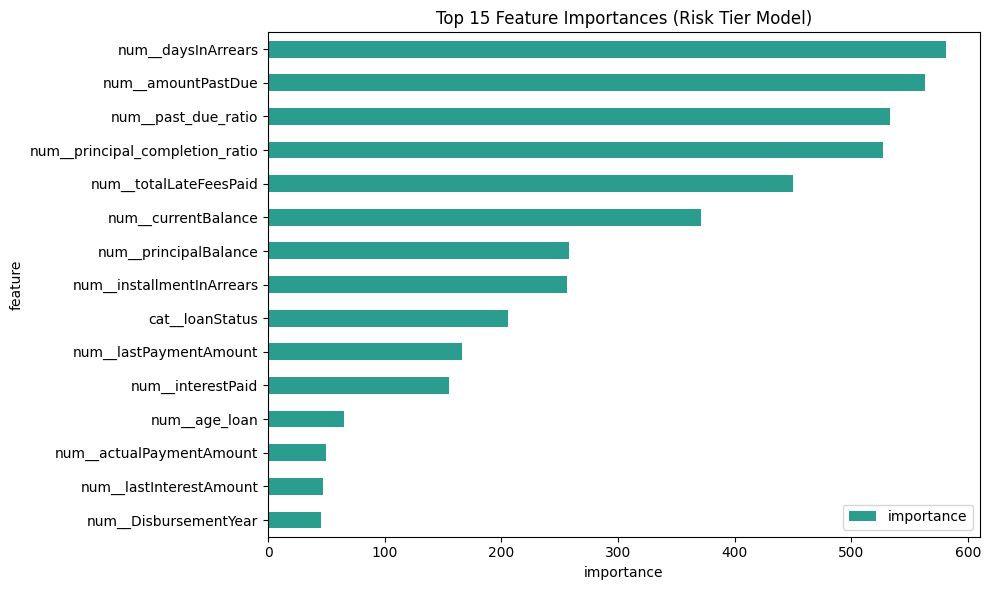

In [7]:
feature_names = preprocess.get_feature_names_out()
risk_clf_obj = advanced_models["risk_tier"]["clf"]

if hasattr(risk_clf_obj, "feature_importances_"):
    fi = np.asarray(risk_clf_obj.feature_importances_)
elif hasattr(risk_clf_obj, "coef_"):
    fi = np.abs(np.asarray(risk_clf_obj.coef_)).mean(axis=0)
else:
    fi = np.zeros(len(feature_names))

fi = fi[: len(feature_names)]
fs_df = pd.DataFrame({"feature": feature_names, "importance": fi})
fs_df = fs_df.sort_values("importance", ascending=False).reset_index(drop=True)

display(fs_df.head(25))

fig, ax = plt.subplots(figsize=(10, 6))
fs_df.head(15).iloc[::-1].plot(kind="barh", x="feature", y="importance", ax=ax, color="#2a9d8f")
ax.set_title("Top 15 Feature Importances (Risk Tier Model)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## 8) Evaluation

Evaluate risk-tier classification and risk-score regression performance.

              precision    recall  f1-score   support

         LOW       1.00      1.00      1.00        95
      MEDIUM       1.00      1.00      1.00      2494
        HIGH       1.00      1.00      1.00      1620

    accuracy                           1.00      4209
   macro avg       1.00      1.00      1.00      4209
weighted avg       1.00      1.00      1.00      4209



,metric,value
0,auc_macro,1.000000
1,qwk,1.000000
2,brier_high_risk,0.000000
3,macro_precision,1.000000
4,macro_recall,1.000000
5,macro_f1,1.000000
6,balanced_accuracy,1.000000
7,high_precision,1.000000
8,high_recall,1.000000
9,high_f1,1.000000


,class,f1,support
0,LOW,1.0,95
1,MEDIUM,1.0,2494
2,HIGH,1.0,1620


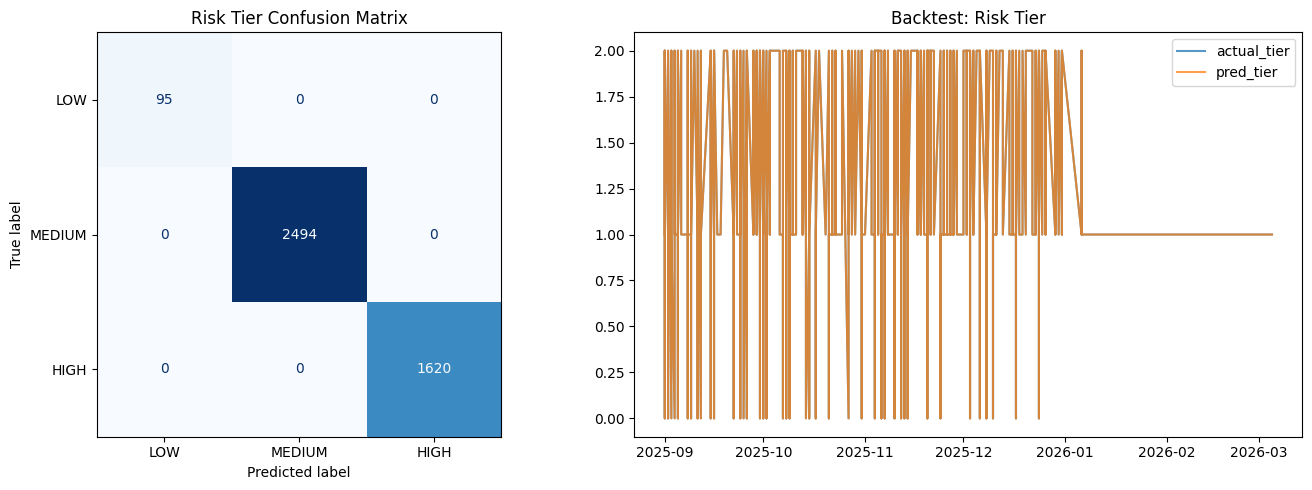

In [8]:
y_test_onehot = pd.get_dummies(y_test_ord_num).reindex(columns=[0, 1, 2], fill_value=0)
auc_macro = roc_auc_score(y_test_onehot, adv_ord_proba, multi_class="ovr", average="macro")
qwk = cohen_kappa_score(y_test_ord_num, adv_ord_pred, weights="quadratic")
brier_high = brier_score_loss((y_test_ord_num == 2).astype(int), adv_ord_proba[:, 2])

rmse_score = float(np.sqrt(mean_squared_error(y_test_score, adv_score_pred)))
mae_score = float(mean_absolute_error(y_test_score, adv_score_pred))

macro_precision = precision_score(y_test_ord_num, adv_ord_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test_ord_num, adv_ord_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test_ord_num, adv_ord_pred, average="macro", zero_division=0)
balanced_acc = balanced_accuracy_score(y_test_ord_num, adv_ord_pred)
_, _, class_f1, class_support = precision_recall_fscore_support(
    y_test_ord_num, adv_ord_pred, labels=[0, 1, 2], zero_division=0
)
high_precision = precision_score((y_test_ord_num == 2).astype(int), (adv_ord_pred == 2).astype(int), zero_division=0)
high_recall = recall_score((y_test_ord_num == 2).astype(int), (adv_ord_pred == 2).astype(int), zero_division=0)
high_f1 = f1_score((y_test_ord_num == 2).astype(int), (adv_ord_pred == 2).astype(int), zero_division=0)

metrics_df = pd.DataFrame([
    {"metric": "auc_macro", "value": round(float(auc_macro), 6)},
    {"metric": "qwk", "value": round(float(qwk), 6)},
    {"metric": "brier_high_risk", "value": round(float(brier_high), 6)},
    {"metric": "macro_precision", "value": round(float(macro_precision), 6)},
    {"metric": "macro_recall", "value": round(float(macro_recall), 6)},
    {"metric": "macro_f1", "value": round(float(macro_f1), 6)},
    {"metric": "balanced_accuracy", "value": round(float(balanced_acc), 6)},
    {"metric": "high_precision", "value": round(float(high_precision), 6)},
    {"metric": "high_recall", "value": round(float(high_recall), 6)},
    {"metric": "high_f1", "value": round(float(high_f1), 6)},
    {"metric": "risk_score_rmse", "value": round(float(rmse_score), 6)},
    {"metric": "risk_score_mae", "value": round(float(mae_score), 6)},
])

class_metrics_df = pd.DataFrame({
    "class": ["LOW", "MEDIUM", "HIGH"],
    "f1": class_f1.round(6),
    "support": class_support,
})

print(classification_report(y_test_ord_num, adv_ord_pred, target_names=risk_order, zero_division=0))
display(metrics_df)
display(class_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test_ord_num, adv_ord_pred, labels=[0, 1, 2]), display_labels=risk_order).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Risk Tier Confusion Matrix")

if "disbursementDate" in model_df.columns and len(X_test) > 0:
    time_idx = model_df.iloc[X_test.index]["disbursementDate"]
else:
    time_idx = np.arange(len(X_test))

axes[1].plot(time_idx, y_test_ord_num.values, label="actual_tier", alpha=0.75)
axes[1].plot(time_idx, adv_ord_pred, label="pred_tier", alpha=0.75)
axes[1].set_title("Backtest: Risk Tier")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9) Calibration

Calibrate and inspect high-risk probability reliability.

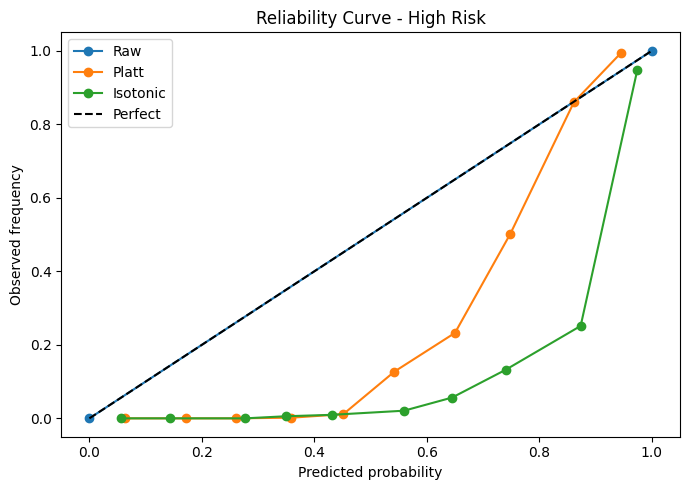

In [9]:
high_train = (y_train_ord_num == 2).astype(int)
high_test = (y_test_ord_num == 2).astype(int)

base_binary = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])

cal_sigmoid = CalibratedClassifierCV(base_binary, method="sigmoid", cv=3)
cal_isotonic = CalibratedClassifierCV(base_binary, method="isotonic", cv=3)
cal_sigmoid.fit(X_train, high_train)
cal_isotonic.fit(X_train, high_train)

p_raw = adv_ord_proba[:, 2]
p_sig = cal_sigmoid.predict_proba(X_test)[:, 1]
p_iso = cal_isotonic.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for probs, label in [(p_raw, "Raw"), (p_sig, "Platt"), (p_iso, "Isotonic")]:
    frac_pos, mean_pred = calibration_curve(high_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], "k--", label="Perfect")
ax.set_title("Reliability Curve - High Risk")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 10) Explainability

Use partial dependence plots for key numeric features in the risk-tier model.

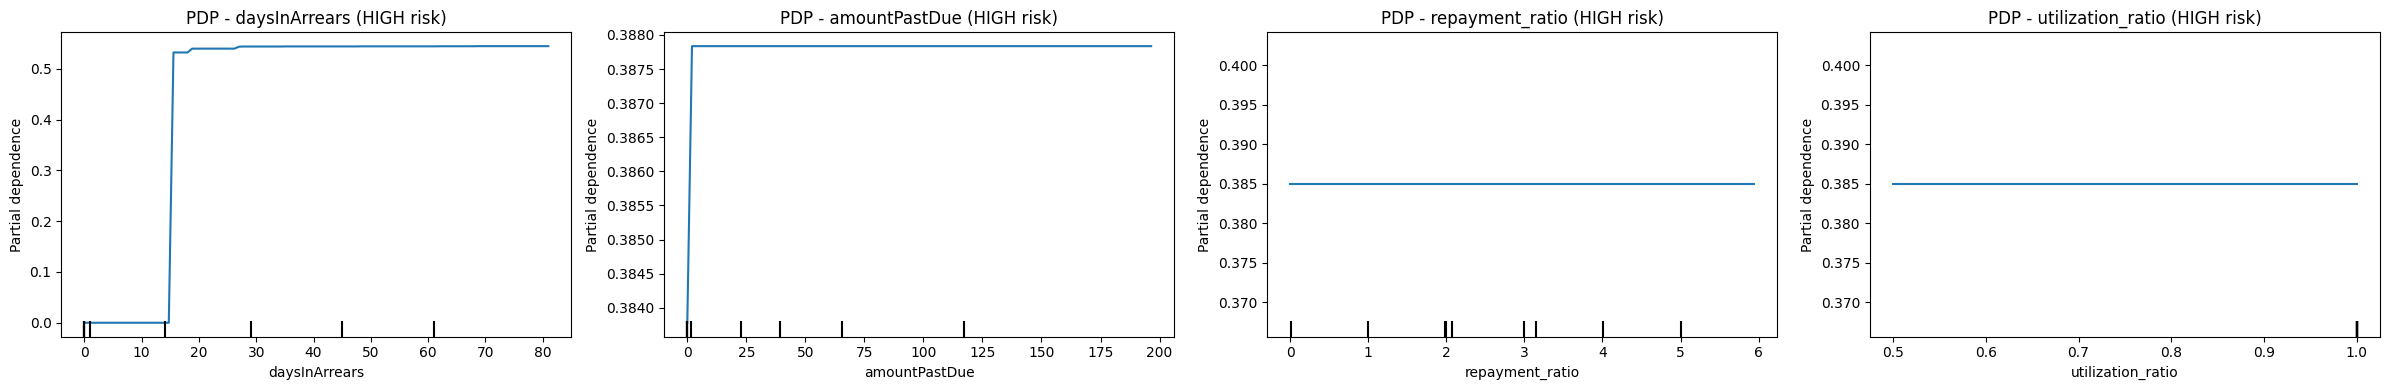

In [10]:
try:
    candidate = [c for c in ["daysInArrears", "amountPastDue", "repayment_ratio", "utilization_ratio"] if c in X_test.columns]
    if len(candidate) < 2:
        candidate = [c for c in num_cols if c in X_test.columns][:2]

    if not candidate:
        raise ValueError("No numeric features available for partial dependence")

    fig, ax = plt.subplots(1, len(candidate), figsize=(6 * len(candidate), 4))
    if len(candidate) == 1:
        ax = [ax]

    for i, feat in enumerate(candidate):
        PartialDependenceDisplay.from_estimator(
            advanced_models["risk_tier"],
            X_test,
            [feat],
            target=2,
            ax=ax[i],
        )
        ax[i].set_title(f"PDP - {feat} (HIGH risk)")

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("PDP skipped:", e)

## 11) Inference Pipeline

Batch risk scoring and risk-only artifact export.

In [11]:
import joblib

def score_batch(df_features: pd.DataFrame) -> pd.DataFrame:
    out = df_features.copy()
    tier_pred_num = advanced_models["risk_tier"].predict(df_features)
    tier_proba = advanced_models["risk_tier"].predict_proba(df_features)
    inv_ord_map = {v: k for k, v in ord_map.items()}

    out["pred_risk_tier_3m"] = pd.Series(tier_pred_num).map(inv_ord_map).values
    out["pred_risk_tier_low_p"] = tier_proba[:, 0]
    out["pred_risk_tier_medium_p"] = tier_proba[:, 1]
    out["pred_risk_tier_high_p"] = tier_proba[:, 2]
    out["pred_risk_score_3m"] = np.clip(advanced_models["risk_score"].predict(df_features), 0, 1)
    return out

scored_test = score_batch(X_test)
base_test = model_df.iloc[X_test.index][["ClientId", "BaselineEndlineClientId", TARGET_ORDINAL, TARGET_SCORE]].reset_index(drop=True)
scored_test_export = base_test.join(
    scored_test[[
        "pred_risk_tier_3m",
        "pred_risk_tier_low_p",
        "pred_risk_tier_medium_p",
        "pred_risk_tier_high_p",
        "pred_risk_score_3m",
    ]].reset_index(drop=True)
)

joblib.dump(advanced_models["risk_tier"], MODELS_DIR / "risk_tier_3m_model.joblib")
joblib.dump(advanced_models["risk_score"], MODELS_DIR / "risk_score_3m_model.joblib")
scored_test_export.to_csv(PREDICTIONS_DIR / "risk_predictions_test.csv", index=False)

print("Saved risk models and predictions")
print("-", MODELS_DIR / "risk_tier_3m_model.joblib")
print("-", MODELS_DIR / "risk_score_3m_model.joblib")
print("-", PREDICTIONS_DIR / "risk_predictions_test.csv")
display(scored_test_export.head(5))

Saved risk models and predictions
- /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/models/risk_tier_3m_model.joblib
- /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/models/risk_score_3m_model.joblib
- /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/predictions/risk_predictions_test.csv


,ClientId,BaselineEndlineClientId,risk_tier_3m,risk_score_3m,pred_risk_tier_3m,pred_risk_tier_low_p,pred_risk_tier_medium_p,pred_risk_tier_high_p,pred_risk_score_3m
0,9489E0B858EA4724,nan,MEDIUM,0.026194,MEDIUM,3.851075e-08,9.999999e-01,7.308030e-08,0.026502
1,62BCC1DDF9E8176D,nan,HIGH,0.102315,HIGH,1.139670e-08,2.071356e-08,1.000000e+00,0.102119
2,D5D0095ADE4582E8,nan,MEDIUM,0.020842,MEDIUM,3.373064e-08,9.999999e-01,9.823781e-08,0.021262
3,C6159F9591CC877E,nan,MEDIUM,0.008640,MEDIUM,2.096585e-08,9.999999e-01,5.933721e-08,0.008636
4,529F5E45718527B4,nan,LOW,0.008640,LOW,9.999999e-01,3.251933e-08,3.961962e-08,0.008644


## 12) Reporting

Export risk-only metrics and segment summaries for decision support.

In [12]:
print("Risk-only reporting cell")

Risk-only reporting cell


,metric,value
0,auc_macro,1.000000
1,qwk,1.000000
2,brier_high_risk,0.000000
3,macro_precision,1.000000
4,macro_recall,1.000000
5,macro_f1,1.000000
6,balanced_accuracy,1.000000
7,high_precision,1.000000
8,high_recall,1.000000
9,high_f1,1.000000


,pred_tier,clients,mean_pred_risk,mean_actual_risk,mean_high_prob
0,HIGH,1620,0.046642,0.046644,9.999996e-01
1,LOW,95,0.008645,0.008640,4.166378e-08
2,MEDIUM,2494,0.012319,0.012296,8.081740e-07


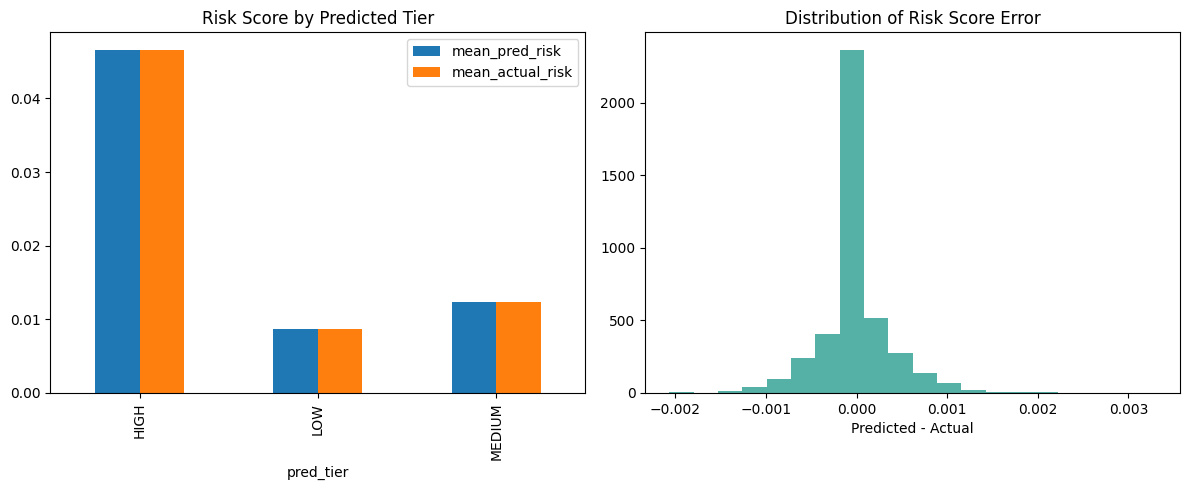

Reporting assets exported:
- /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/metrics/risk_model_summary_metrics.csv
- /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/metrics/risk_segment_summary.csv
- /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/predictions/risk_predictions_test.csv


In [13]:
summary_df = metrics_df.copy()
summary_df.to_csv(METRICS_DIR / "risk_model_summary_metrics.csv", index=False)

portfolio_view = scored_test_export.copy()
portfolio_view["risk_score_gap"] = portfolio_view["pred_risk_score_3m"] - portfolio_view[TARGET_SCORE]

segment_summary = (
    portfolio_view
    .assign(pred_tier=portfolio_view["pred_risk_tier_3m"])
    .groupby("pred_tier", as_index=False)
    .agg(
        clients=("ClientId", "count"),
        mean_pred_risk=("pred_risk_score_3m", "mean"),
        mean_actual_risk=(TARGET_SCORE, "mean"),
        mean_high_prob=("pred_risk_tier_high_p", "mean"),
    )
    .sort_values("pred_tier")
)
segment_summary.to_csv(METRICS_DIR / "risk_segment_summary.csv", index=False)

display(summary_df)
display(segment_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
segment_summary.plot.bar(x="pred_tier", y=["mean_pred_risk", "mean_actual_risk"], ax=axes[0], title="Risk Score by Predicted Tier")
axes[1].hist(portfolio_view["risk_score_gap"], bins=20, alpha=0.8, color="#2a9d8f")
axes[1].set_title("Distribution of Risk Score Error")
axes[1].set_xlabel("Predicted - Actual")
plt.tight_layout()
plt.show()

print("Reporting assets exported:")
print("-", METRICS_DIR / "risk_model_summary_metrics.csv")
print("-", METRICS_DIR / "risk_segment_summary.csv")
print("-", PREDICTIONS_DIR / "risk_predictions_test.csv")